In [1]:
import sys 
sys.path.append('..')
sys.path.append('../src')
sys.path.append('../Depth-Anything-V2')

In [2]:
from waypoint_dataset import WaypointDataset
from model_context import ModelContextV2


Using device: mps


In [190]:
import torch
import torchvision.transforms as transforms
import numpy as np

data_folder = 'outside_office_v2'

model_context = ModelContextV2(waypoint_num=4, num_prev_observations=0, levels=[16, 32, 64], height=280, width=280, embedding_dim=128, hidden_dim=256, attention_blocks=2)

transform = transforms.Compose([
    transforms.Resize((model_context.height, model_context.width)),
    transforms.ToTensor(),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.4),
    transforms.Normalize(mean=model_context.mean, std=model_context.std)])

## 5fps so a frame every second as context.
frame_skips = 5
waypoint_skips = 2
dataset = WaypointDataset(data_folder=data_folder, frame_skips = frame_skips, waypoint_skips=waypoint_skips, model_context=model_context, transform=transform)

Using device: mps


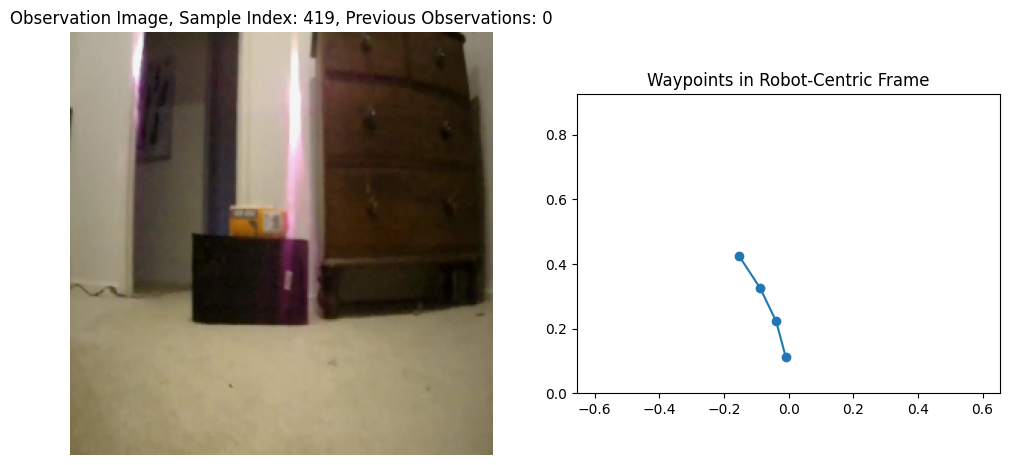

In [192]:
sample_idx = np.random.randint(0, len(dataset))
dataset.view_sample(sample_idx, num_prev_observations=0)

In [9]:
import math
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.half_dim = self.dim // 2
        self.emb_calc = math.log(10000) / (self.half_dim - 1)

    def forward(self, x):
        """
        x is the time embedding and is translated to a sinusoidal postional embedding.
        """
        device = x.device
        emb = torch.exp(torch.arange(self.half_dim, device=device) * -self.emb_calc)
        ## here we are unsquezee the vectors to get (B, 1) * (1, half_dim)
        emb = x[:, None] * emb[None, :] # [B, half_dim]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1) # [B, dim]
        return emb
    
def visualize_sinusoidal(dim=8, x_min=0, x_max=200, num_points=500):
    """
    Visualize the sinusoidal embedding of scalar x in [x_min, x_max] for each embedding dimension.
    """
    model = SinusoidalPosEmb(dim)
    # Create a grid of x values
    xs = torch.linspace(x_min, x_max, num_points)
    print(xs.shape)
    with torch.no_grad():
        emb = model(xs)  # shape (num_points, dim)
    print(emb.shape)

    emb = emb.cpu().numpy()
    xs_np = xs.cpu().numpy()

    # Plot each embedding dimension as a separate curve
    plt.figure(figsize=(10, 6))
    for i in range(dim):
        plt.plot(xs_np, emb[:, i], label=f"dim {i}")
    plt.title(f"Sinusoidal Positional Embedding (dim={dim})")
    plt.xlabel("x (position / time)")
    plt.ylabel("embedding value")
    plt.legend(bbox_to_anchor=(1.0, 1.0))
    plt.tight_layout()
    plt.show()

#visualize_sinusoidal(dim=16, x_min=0, x_max=5, num_points=5)

In [10]:
from model_v1 import ResetNetBlock, ActionHead
import torch 
import torch.nn as nn
import torch.nn.functional as F
from depth_anything_v2.dpt import DepthAnythingV2

model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}


class Encoder(nn.Module):
    def __init__(self, model_context, in_chans = 3, kernel_size=3, n_groups=8):
        super().__init__()
        self.levels = levels = model_context.levels
        self.blocks = nn.ModuleList()

        zipped_levels = zip([in_chans] + levels[:-1], levels)

        for (in_ch, out_ch) in zipped_levels:
            self.blocks.append(nn.Sequential(ResetNetBlock(in_ch, out_ch, kernel_size, n_groups),
                                             nn.MaxPool2d(kernel_size=2, stride=2)))
            
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.linear = nn.Linear(levels[-1], model_context.embedding_dim)
                                             

    def forward(self, x):
        for block in self.blocks:
            x = block(x) 
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.linear(x)
        return x

class AttentionBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, dropout=dropout, batch_first=True)
        self.norm_a = nn.LayerNorm(embed_dim)

        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.Mish(),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm_b = nn.LayerNorm(embed_dim)

    def forward(self, x):
        attn_output, _ = self.mha(x, x, x)
        x = self.norm_a(x + attn_output)
        ffn_output = self.ff(x)
        x = self.norm_b(x + ffn_output)
        return x
    
class TransformerEncoder(nn.Module):
    def __init__(self, in_dim, num_layers=2, num_heads=4, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([
            AttentionBlock(embed_dim=in_dim, num_heads=num_heads, dropout=dropout)
            for _ in range(num_layers)
        ])
        self.output_proj = nn.Linear(in_dim, in_dim)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        x = self.output_proj(x)
        return x


class DepthMap(nn.Module):
    def __init__(self, model_context, kernel_size=3):
        super().__init__()
        self.model_context = model_context
        encoder = 'vits' # or 'vits', 'vitb', 'vitg'
        depth_model = DepthAnythingV2(**model_configs[encoder])
        depth_model.load_state_dict(torch.load(f'/Users/tom/Development/carbot_ai_model/models/depth/depth_anything_v2_{encoder}.pth', map_location='cpu'))
        depth_model = depth_model.to(model_context.device).to(model_context.data_type).eval()

        for param in depth_model.parameters():
            param.requires_grad = False

        self.depth_model = depth_model

        self.depth_encoder = Encoder(model_context=model_context, in_chans = 1, kernel_size=kernel_size)

    # Expects input shape (B, O, C, H, W)
    def forward(self, x):
        curr_x = x[:, 0, :, :, :]
        with torch.no_grad():
            depth_map = self.depth_model(curr_x)
            depth_map = F.interpolate(depth_map[:, None], (self.model_context.height, self.model_context.width), mode="bilinear", align_corners=True)
        depth_encoded = self.depth_encoder(depth_map)
        return depth_encoded
    

class ModelV2(nn.Module):
    def __init__(self, model_context, kernel_size=3, dropout=0.2):
        super().__init__()
        C, H, W = model_context.channels, model_context.height, model_context.width
        T = model_context.num_prev_observations + 1  # Current observation + previous observations
        self.embd_dim = model_context.embedding_dim

        self.depth_map = DepthMap(model_context=model_context).to(model_context.device)

        self.encoder = Encoder(model_context=model_context, in_chans = C, kernel_size=kernel_size)
        

        self.context_encoder = TransformerEncoder(in_dim=model_context.embedding_dim, num_layers=model_context.attention_blocks, num_heads=4, dropout=dropout)
        ## since the time intervals are constant we can precompute the time embeddings. 
        sin_emb = SinusoidalPosEmb(self.embd_dim) 
        tx = torch.linspace(0, T - 1, T).to(model_context.device).to(model_context.data_type)
        with torch.no_grad():
            self.time_emb = sin_emb(tx)


        self.action_head = ActionHead(embed_dim=self.embd_dim, waypoint_num=model_context.waypoint_num, dropout=dropout)
    ## expects input shape (B, O, C, H, W)
    def forward(self, x):
        B, T, C, H, W = x.shape

        depth_emb = self.depth_map(x).view(B, 1, -1)  # Shape (B, 1, embd_dim)

        x = x.view(B * T, C, H, W)
        x = self.encoder(x)
        x = x.view(B, T, -1)  # Reshape back to (B, O, context_emb_dim)

        x = x + self.time_emb[None, :, :]
        x = torch.cat([depth_emb, x], dim=1)  # Concatenate depth embedding

        # Expects input shape (B, T, context_emb_dim)
        x = self.context_encoder(x)

        x = torch.mean(x, dim=1)  # Aggregate over time dimension
        out = self.action_head(x)
        return out


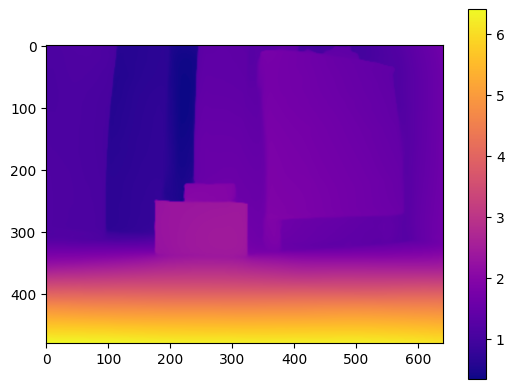

In [6]:
import cv2
import torch
import numpy as np
from matplotlib import pyplot as plt

from depth_anything_v2.dpt import DepthAnythingV2

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'


model_configs = {
    'vits': {'encoder': 'vits', 'features': 64, 'out_channels': [48, 96, 192, 384]},
    'vitb': {'encoder': 'vitb', 'features': 128, 'out_channels': [96, 192, 384, 768]},
    'vitl': {'encoder': 'vitl', 'features': 256, 'out_channels': [256, 512, 1024, 1024]},
    'vitg': {'encoder': 'vitg', 'features': 384, 'out_channels': [1536, 1536, 1536, 1536]}
}

encoder = 'vits' # or 'vits', 'vitb', 'vitg'


class DepthModelInference(nn.Module):
    def __init__(self, encoder='vits', model_context=model_context):
        super().__init__()
        self.model = DepthAnythingV2(**model_configs[encoder])
        self.model.load_state_dict(torch.load(f'../models/depth/depth_anything_v2_{encoder}.pth', map_location='cpu'))
        self.model = self.model.to(DEVICE).eval()
        self.model_context = model_context

    def forward(self, x):
        with torch.no_grad():
            depth = self.model(x)
            depth_map = F.interpolate(depth[:, None], (self.model_context.height, self.model_context.width), mode="bilinear", align_corners=True)
        return depth_map


model = DepthAnythingV2(**model_configs[encoder])
model.load_state_dict(torch.load(f'../models/depth/depth_anything_v2_{encoder}.pth', map_location='cpu'))
model = model.to(DEVICE).eval()

raw_img = cv2.imread('../processed_trajectories/outside_hallway_v2/trajectory_2/frame_1.png')
depth = model.infer_image(raw_img, 280) # HxW raw depth map in numpy

plt.imshow(depth, cmap='plasma')
plt.colorbar()
plt.show()




torch.Size([1, 3, 280, 280])
torch.Size([1, 1, 280, 280])


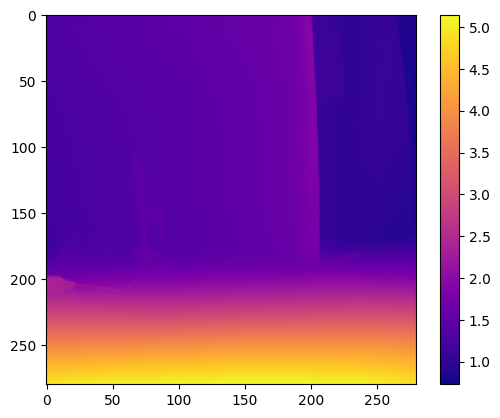

torch.Size([1, 3, 280, 280])


/var/folders/94/b4rb28zd70zg_3hd1pz8r6rh0000gn/T/ipykernel_30700/1193433003.py:29: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(depth_model,
/Users/tom/Development/carbot_ai_model/EPV/../Depth-Anything-V2/depth_anything_v2/dinov2_layers/patch_embed.py:73: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in t

ONNX model is valid.


In [7]:
import onnx


sample_idx = np.random.randint(0, len(dataset))
o_t, w = dataset[sample_idx]
o_t = o_t[0, :, :, :].unsqueeze(0)

print(o_t.shape)

depth_model = DepthModelInference(encoder=encoder, model_context=model_context)
depth_map = depth_model.forward(o_t)


print(depth_map.shape)
depth_map = depth_map.squeeze(0)

depth_map = depth_map.permute(1, 2, 0).cpu().numpy()
plt.imshow(depth_map[:, :, 0], cmap='plasma')
plt.colorbar()
plt.show()



model_name = 'depth'

output_onnx_path = f'../models/{model_name}/{model_name}.onnx'
dummy_input = torch.randn(1, 3, model_context.height, model_context.width).to(model_context.device).to(model_context.data_type)
print(dummy_input.shape)
torch.onnx.export(depth_model, 
                    dummy_input, 
                    output_onnx_path, 
                    opset_version=18,
                    export_params=True,
                    input_names=['input'],
                    output_names=['output'],
                    dynamo=False)

onnx_model = onnx.load(output_onnx_path)
onnx.checker.check_model(onnx_model)
print("ONNX model is valid.")




In [14]:
model = ModelV2(model_context).to(model_context.device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

dummy_input = torch.randn(16, model_context.num_prev_observations + 1, model_context.channels, model_context.height, model_context.width).to(model_context.device)
with torch.no_grad():
    dummy_output = model(dummy_input)
print("Dummy input shape:", dummy_input.shape)
print("Dummy output shape:", dummy_output.shape)

Total parameters: 25,467,011
Dummy input shape: torch.Size([16, 1, 3, 280, 280])
Dummy output shape: torch.Size([16, 6, 2])


In [ ]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

batch_size = 1
train_split = 0.90

train_idx, val_idx = train_test_split(list(range(len(dataset))), train_size=train_split, random_state=42)

  # Create data loaders
train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)

train_loader = DataLoader(dataset, batch_size=batch_size,
                            sampler=train_sampler, num_workers=0)
val_loader = DataLoader(dataset, batch_size=batch_size, 
                        sampler=val_sampler, num_workers=0)

In [ ]:

## Setup optimizer and loss function
train_iters = 20
learning_rate = 1e-3
warmup_steps = 2000

def warmup_lr(step):
    return min(step, warmup_steps) / warmup_steps


optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=learning_rate)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, warmup_lr)
criterion = nn.MSELoss()

dummy_input = torch.randn(2, model_context.num_prev_observations + 1, model_context.channels, model_context.height, model_context.width).to(model_context.device)
with torch.no_grad():
    dummy_output = model(dummy_input)
print("Dummy output shape:", dummy_output.shape)

In [ ]:
from train import train_model, view_val_train_loss

In [ ]:
avg_losses, avg_val_losses = train_model(model = model,
                                         train_loader = train_loader,
                                         val_loader = val_loader,
                                         criterion = criterion,
                                         optimizer = optimizer,
                                         scheduler = scheduler,
                                         train_iters = train_iters,
                                         save_model_path = data_folder,
                                         model_context = model_context, 
                                         custom_loss = True)

In [58]:
best_model = ModelV2(model_context=model_context).to(model_context.device)
best_model.load_state_dict(torch.load(f'../models/{data_folder}/best_model.pth'))

<All keys matched successfully>

torch.Size([3, 280, 280])


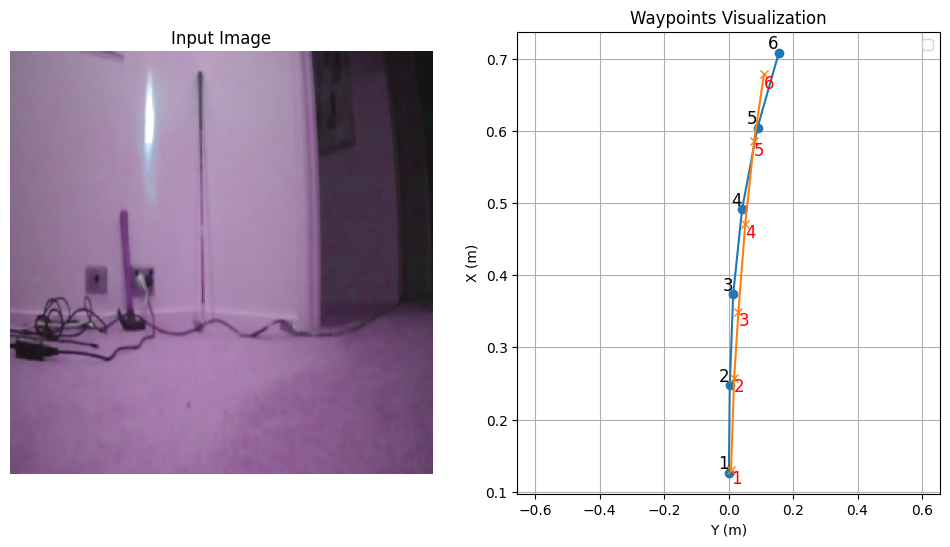

116


In [79]:
import numpy as np
from train import view_evaluation_sample

best_model.eval()

sample_idx = np.random.randint(0, len(dataset))
o_t, waypoints = dataset[sample_idx]
view_evaluation_sample(o_t, waypoints, best_model, model_context)
print(sample_idx)

In [45]:
import onnx

def export_model_to_onnx_v2(output_model, data_dir, model_name, model_context):
    output_model.eval()
    output_onnx_path = f'../models/{data_dir}/{model_name}.onnx'
    dummy_input = torch.randn(1, model_context.num_prev_observations + 1, model_context.channels, model_context.height, model_context.width).to(model_context.device).to(model_context.data_type)
    torch.onnx.export(output_model, 
                        dummy_input, 
                        output_onnx_path, 
                        opset_version=18,
                        export_params=True,
                        input_names=['input'],
                        output_names=['output'],
                        dynamo=False)

    onnx_model = onnx.load(output_onnx_path)
    onnx.checker.check_model(onnx_model)
    print("ONNX model is valid.")
    return onnx_model



onnx_model = export_model_to_onnx_v2(best_model, data_folder, model_name=data_folder, model_context=model_context)

/var/folders/94/b4rb28zd70zg_3hd1pz8r6rh0000gn/T/ipykernel_30700/1235332124.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(output_model,
/Users/tom/Development/carbot_ai_model/EPV/../Depth-Anything-V2/depth_anything_v2/dinov2_layers/patch_embed.py:73: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in t

ONNX model is valid.


torch.Size([3, 280, 280])


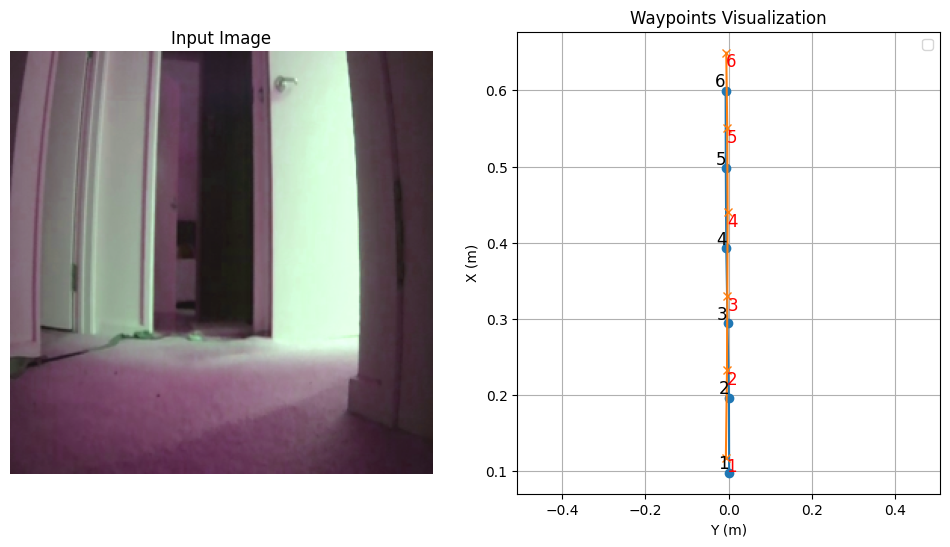

In [48]:
import onnxruntime as ort
import torch
import numpy as np

onnx_path = f'../models/{data_folder}/{data_folder}.onnx'

class ONNXModule(torch.nn.Module):
    def __init__(self, onnx_path):
        super().__init__()
        self.session = ort.InferenceSession(onnx_path)

        # Cache input/output names
        self.input_name = self.session.get_inputs()[0].name
        self.output_name = self.session.get_outputs()[0].name

    def forward(self, x: torch.Tensor):
        # Convert torch → numpy → ORT → numpy → torch
        ort_out = self.session.run(
            [self.output_name],
            {self.input_name: x.detach().cpu().numpy()}
        )[0]

        return torch.from_numpy(ort_out)
    

onnx_model = ONNXModule(onnx_path).to(model_context.device).to(model_context.data_type)

sample_idx = np.random.randint(0, len(dataset))
o_t, waypoints = dataset[sample_idx]
view_evaluation_sample(o_t, waypoints, onnx_model, model_context)




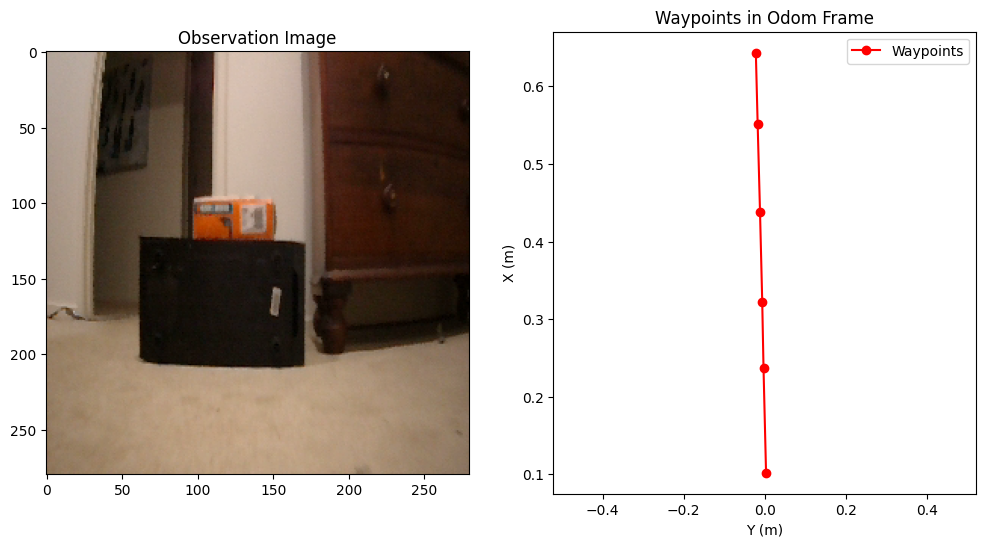

In [57]:
from rollout_reply import ReplayModelRollout

base_arr = '/Users/tom/Development/carbot_ai_model/model_rollouts'
rollout = ReplayModelRollout(data_dir=f'{base_arr}/1763365356', model_context=model_context)
rollout.see_observation(11)

In [98]:
index = 4
context_size = model_context.num_prev_observations

index = index + context_size
obs = rollout.observations[index]

obs_images = []
obs_images.append(obs.image)

prev_obs = []
for i in range(index - context_size, index):
    prev_obs.append(rollout.observations[i].image)

prev_obs.reverse()
obs_images.extend(prev_obs)

obs_image = [image for image in transforms.Normalize(mean=model_context.mean, std=model_context.std)(torch.Tensor(obs_images))]

input_tensor = torch.stack(obs_image).to(model_context.device).to(model_context.data_type)

waypoints = best_model(input_tensor[None, :, :, :, :])


for i in obs.waypoint_in_odom_frame:
    print("x: ", i.x, " y: ", i.y)

print("Predicted waypoints:", waypoints)



x:  0.103277  y:  -0.00220504
x:  0.221398  y:  -0.0154188
x:  0.31443  y:  -0.0317776
x:  0.416157  y:  -0.0557524
x:  0.51709  y:  -0.0842938
x:  0.608191  y:  -0.112
Predicted waypoints: tensor([[[0.0852, 0.0068],
         [0.2159, 0.0096],
         [0.3051, 0.0154],
         [0.4094, 0.0241],
         [0.5208, 0.0367],
         [0.6260, 0.0524]]], device='mps:0', grad_fn=<ViewBackward0>)


In [55]:
array = np.fromfile(f'../output/input_tensor_0.bin', dtype=model_context.data_type_np)
input_tensor_0 = array.reshape(1, 3, model_context.height, model_context.width)

array = np.fromfile(f'../output/input_tensor_1.bin', dtype=model_context.data_type_np)
input_tensor_1 = array.reshape(1, 3, model_context.height, model_context.width)

array = np.fromfile(f'../output/input_tensor_2.bin', dtype=model_context.data_type_np)
input_tensor_2= array.reshape(1, 3, model_context.height, model_context.width)


input_tensor = np.concatenate([input_tensor_2, input_tensor_1, input_tensor_0], axis=0)
input_tensor = torch.Tensor(input_tensor).to(model_context.device).to(model_context.data_type)
input_tensor.shape

output = best_model(input_tensor[None, :, :, :, :])

print("Predicted waypoints from loaded input tensor:", output)


Predicted waypoints from loaded input tensor: tensor([[[ 0.1190,  0.0052],
         [ 0.2377, -0.0009],
         [ 0.3410, -0.0073],
         [ 0.4560, -0.0165],
         [ 0.5685, -0.0261],
         [ 0.6646, -0.0354]]], device='mps:0', grad_fn=<ViewBackward0>)


In [64]:
output_from_model = best_model(torch.Tensor(input_tensor).to(model_context.device).to(model_context.data_type)[None, :, :, :, :])
output_from_model

tensor([[[ 0.1708, -0.0412],
         [ 0.3145, -0.0781],
         [ 0.3917, -0.1014],
         [ 0.4880, -0.1328],
         [ 0.5935, -0.1722],
         [ 0.6851, -0.2085]]], device='mps:0', grad_fn=<ViewBackward0>)